In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"D:\Projects\Smart Customer Support Ticket Router - NLP\Dataset\all_tickets_processed_improved_v3.csv")

In [3]:
df.shape

(47837, 2)

In [4]:
df.head()

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Document     47837 non-null  object
 1   Topic_group  47837 non-null  object
dtypes: object(2)
memory usage: 747.6+ KB


In [6]:
df.isnull().sum()

Document       0
Topic_group    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Topic_group'].unique()

array(['Hardware', 'Access', 'Miscellaneous', 'HR Support', 'Purchase',
       'Administrative rights', 'Storage', 'Internal Project'],
      dtype=object)

In [9]:
df['Topic_group'].nunique()

8

In [10]:
df['Topic_group'].value_counts()

Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64

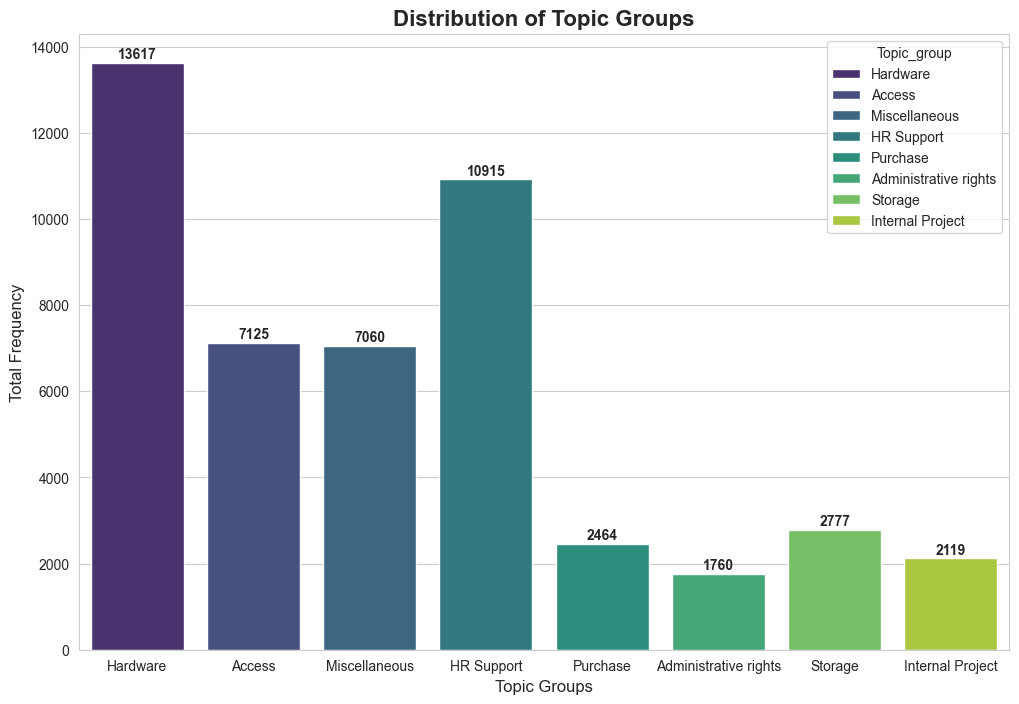

<Figure size 640x480 with 0 Axes>

In [11]:
plt.figure(figsize = (12, 8))
sns.set_style("whitegrid")
countplot = sns.countplot(data = df, x = 'Topic_group', palette='viridis', hue = 'Topic_group', legend = True)

for container in countplot.containers:
    countplot.bar_label(container, padding = 1, fontweight = 'bold')

plt.title('Distribution of Topic Groups', fontsize = 16, fontweight = 'bold')
plt.xlabel('Topic Groups', fontsize = 12)
plt.ylabel('Total Frequency', fontsize = 12)
plt.show()
plt.tight_layout()

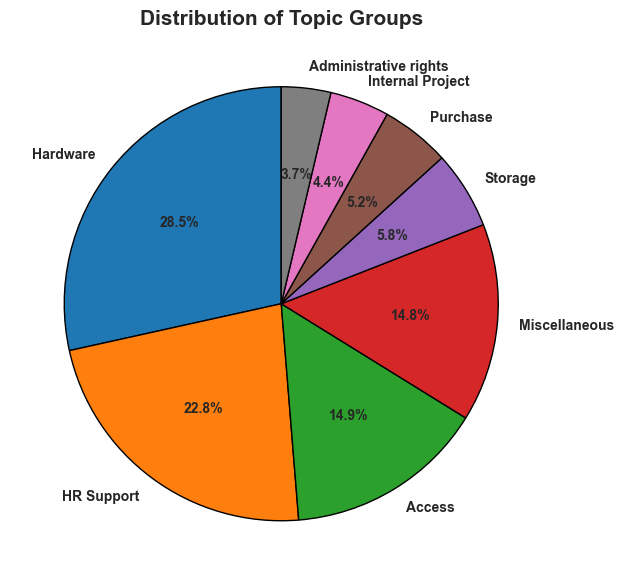

In [12]:
plt.figure(figsize = (7, 9))
pie = df['Topic_group'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor':'black'}
)

for text in pie.texts:
    text.set_fontweight('bold')

plt.ylabel("")
plt.title("Distribution of Topic Groups", fontsize = 15, fontweight = 'bold')
plt.show()

In [13]:
df.head()

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


In [14]:
df['text_length'] = df['Document'].str.split().str.len()

In [15]:
df.head()

,Document,Topic_group,text_length
0,connection with icon icon dear please setup ic...,Hardware,18
1,work experience user work experience user hi w...,Access,19
2,requesting for meeting requesting meeting hi p...,Hardware,14
3,reset passwords for external accounts re expir...,Access,145
4,mail verification warning hi has got attached ...,Miscellaneous,15


In [16]:
df['text_length'].describe()

count    47837.000000
mean        43.597341
std         56.736800
min          2.000000
25%         17.000000
50%         26.000000
75%         46.000000
max        981.000000
Name: text_length, dtype: float64

In [ ]:
# average length per topic
df.groupby('Topic_group')['text_length'].mean().sort_values()

Topic_group
Storage                  34.409795
Purchase                 34.932630
Access                   35.600000
Internal Project         37.706937
HR Support               37.766651
Miscellaneous            42.953966
Administrative rights    50.361932
Hardware                 56.273041
Name: text_length, dtype: float64

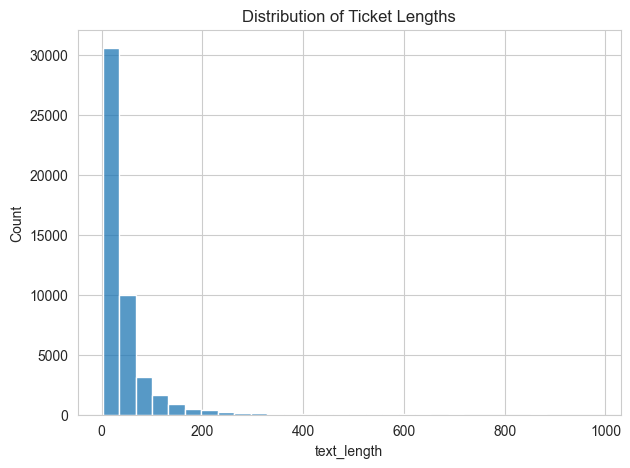

In [17]:
# right skewed
plt.figure(figsize = (7, 5))
sns.histplot(data = df, x = 'text_length', bins = 30)
plt.title('Distribution of Ticket Lengths')
plt.show()

In [22]:
df.to_csv('data.csv', index = False)